In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.seterr(over='ignore', invalid='ignore')
np.random.seed(0)

# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [47]:
# Código
def jacobi(A, b, tol=1e-12, max_iter=1000):
    # Palpite inicial
    x_k = np.zeros(b.size)
    
    # Dividir A em L, D e U
    d = np.diag(A)
    D = np.diag(d)
    L_plus_U = (A - D)
    
    x_errors = []
    residual_errors = []
    
    # Implementando as iterações
    for _ in range(max_iter):
        # Dividir elemento a elemento as linhas pelo vetor d é o mesmo que multiplicar por D^(-1)
        x_k_plus_1 = (b - L_plus_U @ x_k) / d    
    
        # Calculando os erros associados a cada iteração
        delta_steps = np.linalg.norm(x_k_plus_1 - x_k)
        residual_norm = np.linalg.norm(b - A @ x_k_plus_1)
    
        x_errors.append(delta_steps)
        residual_errors.append(residual_norm)

        # Atualizando o palpite
        x_k = x_k_plus_1
        
        # Verificando se o método já convergiu o suficiente
        if (delta_steps < tol) or (residual_norm < tol):
            break

    return x_k, np.array(x_errors), np.array(residual_errors)

#===============================================================
#===============================================================
#===============================================================

def gauss_seidel(A, b, tol=1e-12, max_iter=1000):
    b_size = b.size
    
    # Palpite inicial
    x_k = np.zeros(b_size)
    # Inicializando o x da próxima iteração
    x_k_plus_1 = np.zeros(b_size)
    
    x_errors = []
    residual_errors = []
    
    # Implementando as iterações
    for _ in range(max_iter):
                
        for i in range(b_size):
            aux_x_k = A[i, (i+1):] @ x_k[(i+1):]
                
            aux_x_k_plus_1 = A[i, :i] @ x_k_plus_1[:i]
                
            x_k_plus_1[i] = (b[i] - aux_x_k - aux_x_k_plus_1) / A[i, i]
        
        # Calculando os erros associados a cada iteração
        delta_steps = np.linalg.norm(x_k_plus_1 - x_k)
        residual_norm = np.linalg.norm(b - A @ x_k_plus_1)
    
        x_errors.append(delta_steps)
        residual_errors.append(residual_norm)
        
        x_k = x_k_plus_1.copy()
        
        # Verificando se o método já convergiu o suficiente
        if (delta_steps < tol) or (residual_norm < tol):
            break
    
    return x_k, np.array(x_errors), np.array(residual_errors)

Qual deveria ser a complexidade computacional do código que você escreveu?

## Método de Jacobi
Considere $A$ uma matriz $n \times n$
Na função referente a esse método, calculei a complexidade separadamente:
- **Pré-loop**: Aqui, calculei uma complexidade de $2n^2 + 2n + 5$ apenas contando as operações feitas. Assim, essa parte tem uma complexidade associada de $O(n^2)$.

- **Loop**: Nessa parte é a que de fato fazemos os cálculos com os vetores e matrizes. Desse modo, analisando a equação de iteração, fazemos nela uma multiplicação de matriz com vetor, uma subtração de vetores e uma divisão de cada elemento do vetor. Logo, esse componente vai ter um custo de $(2n -1) \cdot n + n + n = 2n^2 + n$, ou seja, complexidade $O(n^2)$. Além disso, na parte de calcular o ```delta_step``` (norma da subtração de dois vetores) teremos que fazer $2n + 1$ operações, resultando em uma complexidade de $O(n)$. Aliás, no próximo cálculo da norma há uma multiplicação de matriz por vetor, aumentando a complexidade dessa operação para $O(n^2)$. No restante, são apenas custos constantes.

Portanto, no final das contas, a complexidade de uma iteração desse algoritmo implementado é de $O(n^2)$. Como o algoritmo executa $k$ iterações até que o critério de convergência seja atingido (onde $k$ depende da matriz e da tolerância exigida), a complexidade computacional total do algoritmo de Jacobi implementado é de $O(k \cdot n^2)$.

## Método de Gauss-Seidel
Considere, de novo, uma matriz $A_{n \times n}$.
Vamos seguir o mesmo raciocínio:
- **Pré-Loop**: Aqui a complexidade já é menor que do método de Jacobi, pois são feitas: uma operação com custo 1, duas com custo $n$ e duas com custo 1. Assim, essa parte tem complexidade $O(n)$.

- **Loop**: Agora fazemos as iterações e calculamos sequencialmente o $x^{(k+1)}$. Isso porque, diferentemente de Jacobi, para implementar esse método com a inversa de $(D+L)$ nos custaria uma complexidade $O(n^3)$, e é exatamente isso que queremos evitar. Dessa forma, em cada iteração vai nos custar: $2n^2 + 3n$ pelas operações de calcular ```aux_x_k``` e ```aux_x_k_plus_1``` e $2n^2 + 4n + 6$ pelas operações de calcular os erros (há uma multiplicação de matriz por vetor, adicionando o termo quadrático) e atribuições. Logo, a complexidade de cada iteração é $O(n^2)$.

Portanto, considerando $k$ iterações até o critério de convergência ser atingido, temos que a complexidade computacional do algoritmo de Gauss-Seidel implementado é de $O(k \cdot n^2)$.

## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

In [49]:
# Função para comparar os métodos para matrizes pequenas
def comparar_metodos_b(A, b):
    # Gerando matrizes com diagonal dominante para garantir a convergência dos métodos:
    x_j, errors_j, residual_errors_j = jacobi(A, b)
    x_gs, errors_gs, residual_errors_gs = gauss_seidel(A, b)
    x_correto = np.linalg.solve(A, b)
    
    # Printando e plotando as informações
    print(f"Resposta correta: {x_correto}\nSolução encontrada em cada método:\nJacobi: {x_j}\nGauss_Seidel: {x_gs}")
    plt.figure()
    sns.lineplot(data=residual_errors_j, label="Método de Jacobi")
    sns.lineplot(data=residual_errors_gs, label="Método de Gauss_Seidel")
    plt.title("Comparação da velocidade de convergência")
    plt.xlabel("Número de iterações")
    plt.ylabel("Erro Residual")
    plt.yscale("log")
    plt.show()

## Testes para matrizes 2x2
**Observação**: Escolhi matrizes com diagonal dominante para os métodos convergirem.

Resposta correta: [1. 2.]
Solução encontrada em cada método:
Jacobi: [1. 2.]
Gauss_Seidel: [1. 2.]


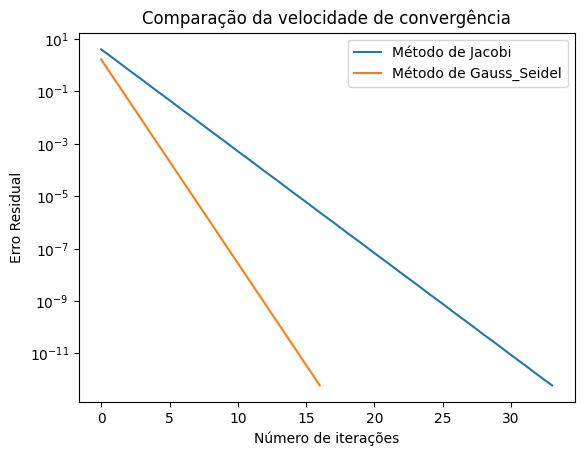

Resposta correta: [2. 1.]
Solução encontrada em cada método:
Jacobi: [2. 1.]
Gauss_Seidel: [2. 1.]


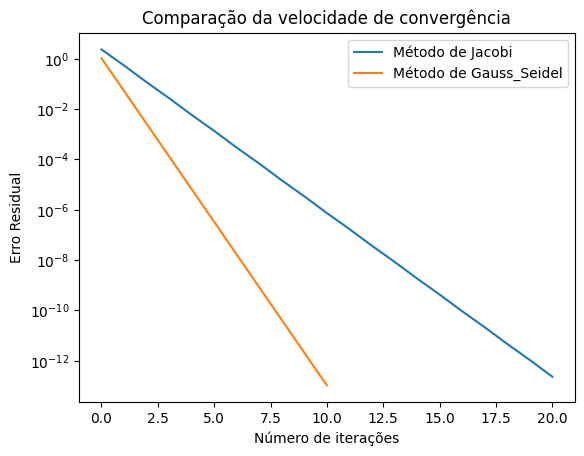

Resposta correta: [ 3. -1.]
Solução encontrada em cada método:
Jacobi: [ 3. -1.]
Gauss_Seidel: [ 3. -1.]


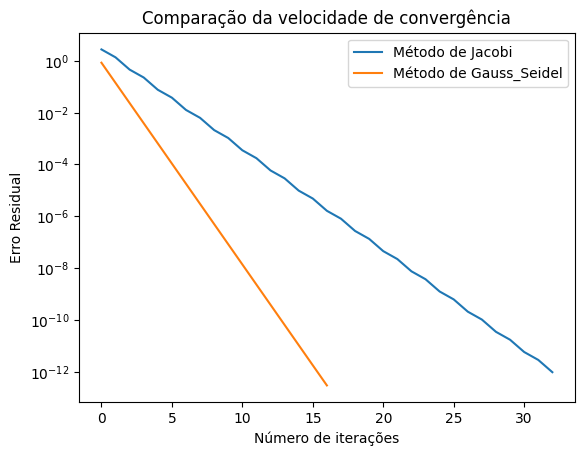

In [50]:
b_1, A_1 = np.array([6, 8]), np.array([[4,1],[2,3]])
b_2, A_2 = np.array([9, 6]), np.array([[5,-1],[1,4]])
b_3, A_3 = np.array([8, 1]), np.array([[3,1],[1,2]])

comparar_metodos_b(A_1, b_1)
comparar_metodos_b(A_2, b_2)
comparar_metodos_b(A_3, b_3)

## Testes para matrizes 3x3

Resposta correta: [1. 2. 3.]
Solução encontrada em cada método:
Jacobi: [1. 2. 3.]
Gauss_Seidel: [1. 2. 3.]


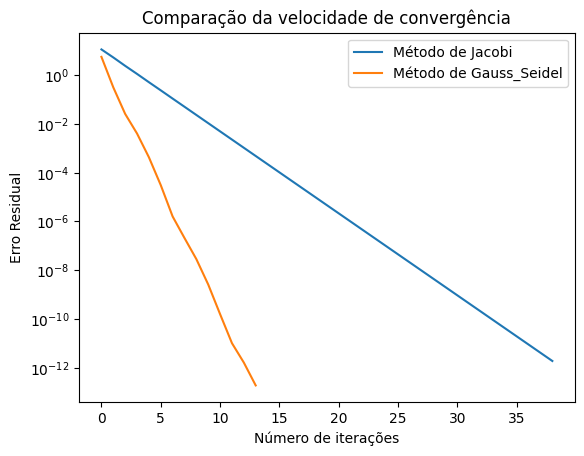

Resposta correta: [2. 1. 1.]
Solução encontrada em cada método:
Jacobi: [2. 1. 1.]
Gauss_Seidel: [2. 1. 1.]


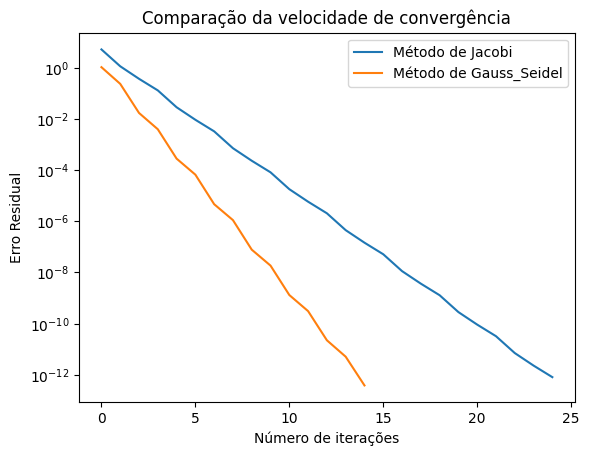

Resposta correta: [ 1. -1.  2.]
Solução encontrada em cada método:
Jacobi: [ 1. -1.  2.]
Gauss_Seidel: [ 1. -1.  2.]


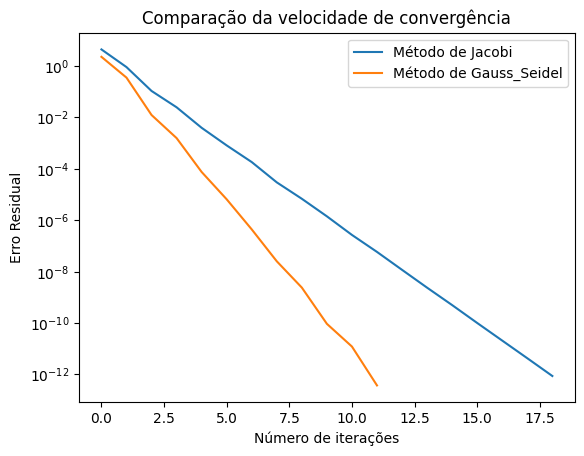

In [51]:
b_1, A_1 = np.array([10, 17, 15]), np.array([[5, 1, 1],[2, 6, 1],[1, 1, 4]])
b_2, A_2 = np.array([8, 6, 11]), np.array([[4, -1, 1],[1, 5, -1],[2, 1, 6]])
b_3, A_3 = np.array([5, -3, 12]), np.array([[6, 1, 0],[2, 7, 1],[1, -1, 5]])

comparar_metodos_b(A_1, b_1)
comparar_metodos_b(A_2, b_2)
comparar_metodos_b(A_3, b_3)

## Comentários
Os dois métodos convergiram à resposta correta em todos os casos. Mas é possível notar que em ambas situações (matrizes 2x2 e matrizes 3x3) o método de Gauss-Siedel foi mais eficiente e convergiu mais rapidamente que o método de Jacobi. Porém, essa diferença, por enquanto nessas dimensões, foi pequena.

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

In [52]:
# Função para comparar os métodos com matrizes rand(m,m) maiores
def comparar_metodos_c(A, b, max_iter=10000): 
    # Gerando matrizes com diagonal dominante para garantir a convergência dos métodos:
    x_j, errors_j, residual_errors_j = jacobi(A, b, max_iter=max_iter, tol=1e-17)
    x_gs, errors_gs, residual_errors_gs = gauss_seidel(A, b, max_iter=max_iter, tol=1e-17)
    
    # Printando e plotando as informações
    plt.figure()
    sns.lineplot(data=residual_errors_j, label="Método de Jacobi")
    sns.lineplot(data=residual_errors_gs, label="Método de Gauss_Seidel")
    plt.title(f"Velocidade de convergência (shape={A.shape})")
    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("Número de Iterações")
    plt.ylabel("Erro Residual")
    plt.legend(loc="upper right")
    plt.show()

## Matrizes maiores com diagonal dominante

In [53]:
def get_mat_diag_dom(size):
    A = np.random.rand(size, size)
    
    # Tornando a diagonal dominante
    for i in range(size):
        A[i,i] += np.sum(np.abs(A[i,:]))
        
    return A

# Para garantir que b esteja no espaço coluna de A
def get_b(A):
    x = np.random.rand(A.shape[0])
    b = A @ x
    return b

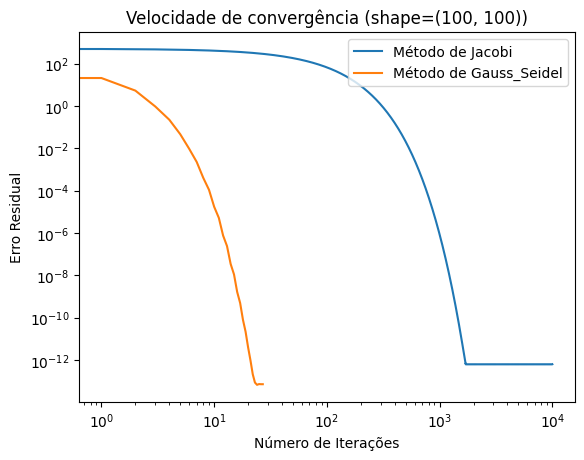

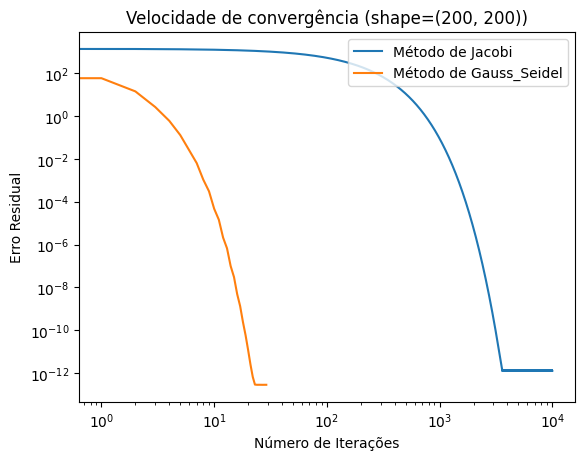

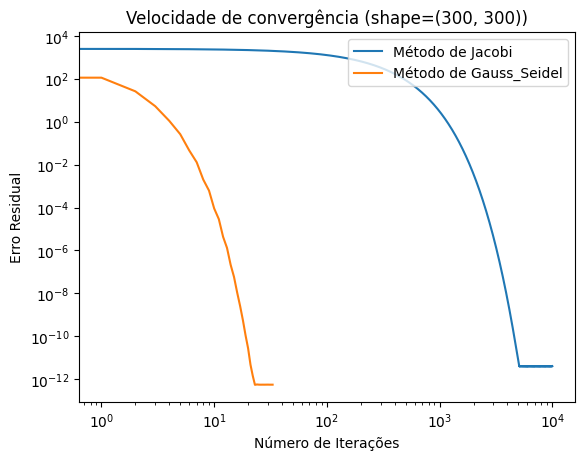

In [54]:
A_1 = get_mat_diag_dom(100)
A_2 = get_mat_diag_dom(200)
A_3 = get_mat_diag_dom(300)

comparar_metodos_c(A_1, get_b(A_1))
comparar_metodos_c(A_2, get_b(A_2))
comparar_metodos_c(A_3, get_b(A_3))

## Matrizes maiores do tipo ```rand(m,m)```

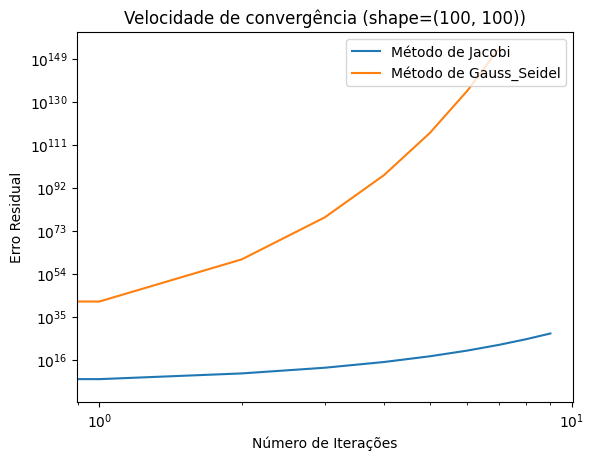

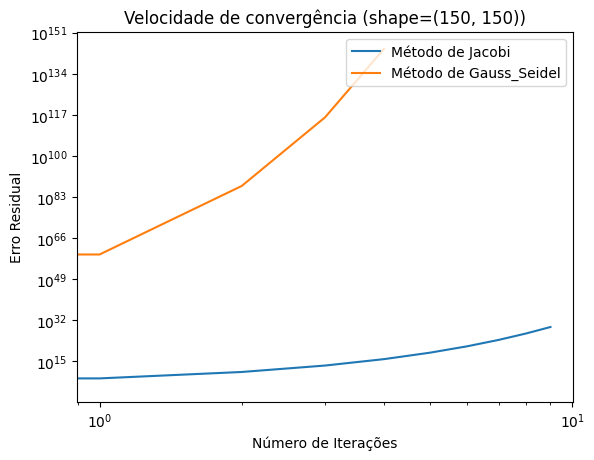

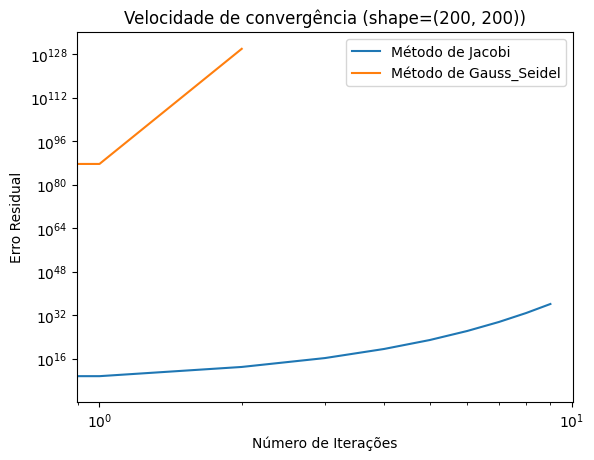

In [56]:
b_1, A_1 = np.random.rand(100), np.random.rand(100, 100)
b_2, A_2 = np.random.rand(150), np.random.rand(150, 150)
b_3, A_3 = np.random.rand(200), np.random.rand(200, 200)

comparar_metodos_c(A_1, get_b(A_1), max_iter=10)
comparar_metodos_c(A_2, get_b(A_2), max_iter=10)
comparar_metodos_c(A_3, get_b(A_3), max_iter=10)

## Comentários
Em geral, percebemos que se nós não normalizarmos a matriz randomizada para ter diagonal dominante, os métodos irão divergir. Ao contrário, se a matriz tiver diagonal dominante, vemos que os métodos continuam funcionando e o Gauss_Seidel continua apresentando uma eficiência muito melhor que o Jacobi (este último leva milhares de iterações a mais para convergir até certo erro de tolerância que nos testes foi de $10^{-12}$).

**Observações**: Não achei pertinente testar com matrizes maiores que isso, pois o comportamento apresentado já foi bem esclarecedor.

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

## Encontrando o $k(m)$:

Somando $m - 1$ variáveis aleatórias em distribuição normal ao redor do 0 com desvio padrão igual a 1, a tendência é que o resultado some 0, mas com desvio padrão $\sqrt{m - 1}$. Porém, se queremos que 95% das matrizes convirjam, não podemos apenas somar $\sqrt{m - 1}$ à diagonal, pois isso é uma "média". Assim, vamos encontrar alguma constante $C$ tal que adicionar $C \cdot \sqrt{m - 1}$ à cada elemento da diagonal faça a matriz convergir em 95% dos casos.

In [260]:
# Função que recebe a dimensão (m) das matrizes que vão ser testadas,
# a constante (C) que vamos testar para analisar o percentual de convergência
# e, possivelmente, o número de testes (N) que vamos fazer
def get_perc_conv(m, C, N=300):
    # Contando o número de convergências
    convergencias_jacobi = 0
    convergencias_gs = 0
        
    # Definindo o k(m) a ser testado
    k = C * np.sqrt(m - 1)
    
    # Criando as matrizes que vamos testar
    M_tests = np.random.randn(N, m, m)
    
    # Realizando os testes
    for i in range(N):
        M = M_tests[i]
        
        # A diagonal da matriz final A será a diagonal de M somada a k
        diag_A = np.diag(M) + k
        
        # Matriz D (diagonal)
        D = np.diag(diag_A)
        
        # Matrizes L e U
        L = np.tril(M, -1)
        U = np.triu(M, 1)
        
        try:
        
            # Matriz de iteração de Jacobi: M_J = - D^(-1) (L + U)
            D_inv = np.diag(1.0 / diag_A)
            M_J = -D_inv @ (L + U)
        
            # Matriz de iteração de Gauss-Seidel: M_GS = - (D + L)^(-1) U
            D_plus_L_inv = np.linalg.inv(D + L)
            M_GS = -D_plus_L_inv @ U
        
            # Verifica a convergência calculando o raio espectral,
            # pois temos que usar a condição necessária, já que com a condição
            # suficiente apenas de ter a diagonal dominante pode nos levar a erros
            raio_espectral_J = np.max(np.abs(np.linalg.eigvals(M_J)))
            raio_espectral_GS = np.max(np.abs(np.linalg.eigvals(M_GS)))
        
            if raio_espectral_J < 1:
                convergencias_jacobi += 1
            
            if raio_espectral_GS < 1:
                convergencias_gs += 1
        
        except:
            # Se a matriz D+L for singular, a tentativa de inversão causa o erro de LinAlgError.
            # Como ela não converge, então só pula para a próxima matriz
            pass
            
    # Retorna a razão de convergência para ambos os métodos
    return convergencias_jacobi / N, convergencias_gs / N

In [261]:
# Tamanhos de matrizes que vamos testar
m_valores = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 400, 450, 500]

# Valores de C que vamos testar
# Estamos analisando até 3 vezes o desvio padrão
C_testes = np.linspace(0.1, 3, 30)

k_otimos = [] # Primeiro k(m) que faz convergir em mais de 95%
c_encontrados = []

for m in m_valores:
    C_otimo_J = 0
    C_otimo_GS = 0
    
    for C in C_testes:
        perc_jacobi, perc_gs = get_perc_conv(m, C, N=300)
        
        # Guarda o primeiro C que faz Gauss-Seidel bater 95%
        if perc_gs >= 0.95 and C_otimo_GS == 0:
            C_otimo_GS = C
            
        # Guarda o primeiro C que faz Jacobi bater 95%
        if perc_jacobi >= 0.95 and C_otimo_J == 0:
            C_otimo_J = C
            
        # Se já achou para os dois, paramos a busca para este m
        if C_otimo_J != 0 and C_otimo_GS != 0:
            break
            
    C_otimo = max(C_otimo_J, C_otimo_GS)
     
    k_necessario = C_otimo * np.sqrt(m - 1)
    
    c_encontrados.append(C_otimo)
    k_otimos.append(k_necessario)

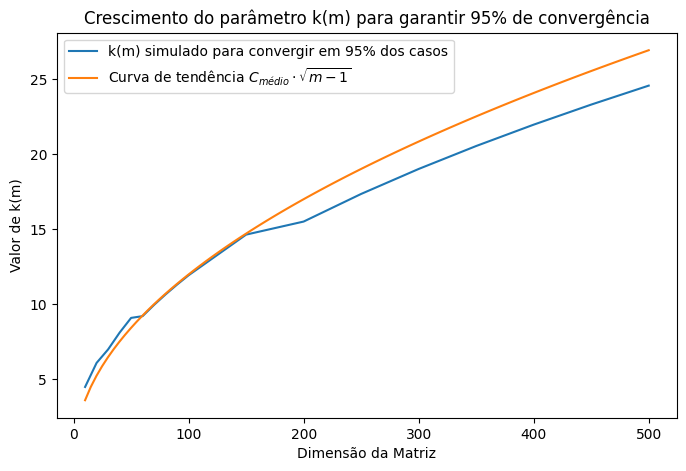

C médio:  1.21


In [262]:
# Média da constante C que funciona para vários valores de m
C_medio = np.mean(c_encontrados)

plt.figure(figsize=(8, 5))

# Plottando os valores da simulação
plt.plot(m_valores, k_otimos, label=r"k(m) simulado para convergir em 95% dos casos")

# Plottando uma curva de tendência com o C médio da simulação
m_continuo = np.linspace(m_valores[0], m_valores[-1], 100)
curva_teorica = C_medio * np.sqrt(m_continuo - 1)

plt.plot(m_continuo, curva_teorica, label=r"Curva de tendência $C_{médio} \cdot \sqrt{m - 1}$")

plt.title(r"Crescimento do parâmetro k(m) para garantir 95% de convergência")
plt.xlabel("Dimensão da Matriz")
plt.ylabel("Valor de k(m)")
plt.legend()

plt.show()

print(30*"=")
print("C médio: ", round(C_medio, 2))
print(30*"=")

## Comentários sobre o $k(m)$
Percebemos que, para os métodos convergirem para 95% dos casos com matrizes do tipo ```randn(m,m)```, $k(m)$ é uma função raiz quadrada de $\sqrt{m - 1}$ (como explicado anteriormente) multiplicada por uma constante $C \approx 1.21$, que achamos empiricamente.

## Analisando a velocidade de convergência:

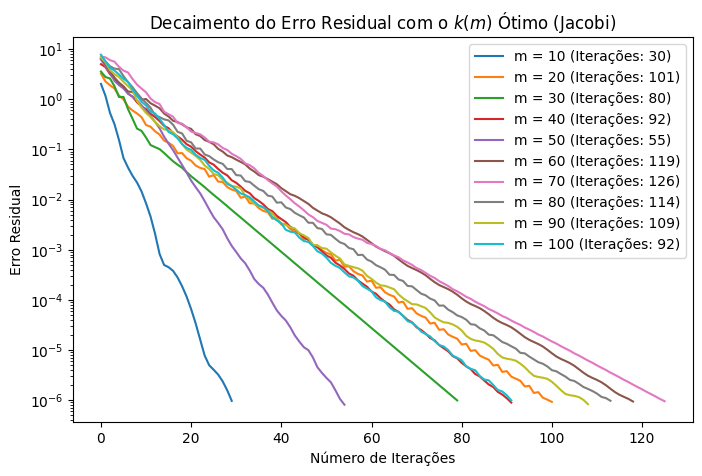

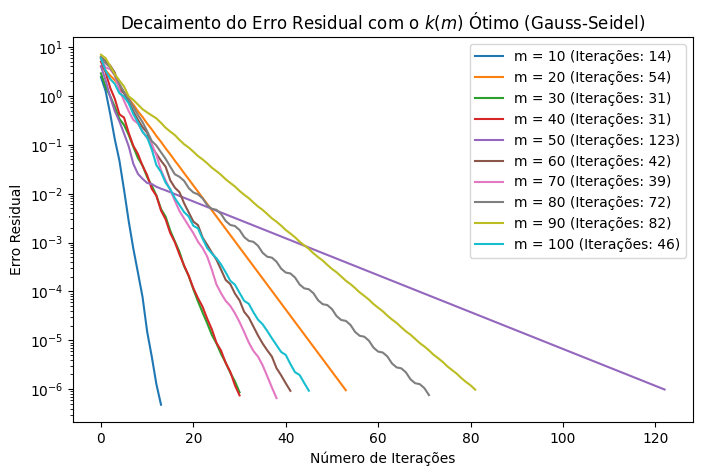

In [66]:
iteracoes_necessarias_jacobi = []

plt.figure(figsize=(8,5))

for i in range(len(m_valores)):
    
    # Criando a matriz no limiar exato
    M = np.random.randn(m_valores[i], m_valores[i])
    A = M.copy()
    np.fill_diagonal(A, np.diag(M) + k_otimos[i])
    
    # Criando um b no espaço coluna de A
    x = np.random.rand(m_valores[i])
    b = A @ x
    
    x_final, lista_erros, lista_passos = jacobi(A, b, tol=1e-6, max_iter=5000)
    
    num_iters = lista_erros.size
    iteracoes_necessarias_jacobi.append(num_iters)
    
    # Adiciona o decaimento do erro do m no gráfico
    plt.plot(lista_erros, label=f'm = {m_valores[i]} (Iterações: {num_iters})')


plt.yscale("log")
plt.title(f"Decaimento do Erro Residual com o $k(m)$ Ótimo (Jacobi)")
plt.xlabel("Número de Iterações")
plt.ylabel("Erro Residual")
plt.legend()

#==================================================================================

iteracoes_necessarias_gs = []

plt.figure(figsize=(8,5))

for i in range(len(m_valores)):
    
    # Criando a matriz no limiar exato
    M = np.random.randn(m_valores[i], m_valores[i])
    A = M.copy()
    np.fill_diagonal(A, np.diag(M) + k_otimos[i])
    
    # Criando um b no espaço coluna de A
    x = np.random.rand(m_valores[i])
    b = A @ x
    
    x_final, lista_erros, lista_passos = gauss_seidel(A, b, tol=1e-6, max_iter=5000)
    
    num_iters = lista_erros.size
    iteracoes_necessarias_gs.append(num_iters)
    
    # Adiciona o decaimento do erro do m no gráfico
    plt.plot(lista_erros, label=f'm = {m_valores[i]} (Iterações: {num_iters})')


plt.yscale("log")
plt.title(f"Decaimento do Erro Residual com o $k(m)$ Ótimo (Gauss-Seidel)")
plt.xlabel("Número de Iterações")
plt.ylabel("Erro Residual")
plt.legend()

plt.show()

## Comentários sobre a velocidade de convergência:
Comparando com os testes dos itens anteriores em que usamos matrizes com diagonais dominantes, percebemos que operar próximo do limiar do $k(m)$ ótimo faz com que o sistema fique estranho, indefinido, talvez por o raio espectral das matrizes de iteração ser muito próximo de 1. Isso porque podemos notar que os métodos tomam muito mais iterações para chegar ao mesmo erro residual. Além de que nessa situação não é tão clara uma relação do tamanho $m$ da matriz com o número de iterações requeridas, já que matrizes menores tomam muito mais iterações em alguns casos.

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

## Minhas ideias:
A condição necessária de convergência é o raio espectral da matriz ser menor que 1 ($| \rho | < 1$), ou seja, todos os autovalores tem que ter módulo menor que 1. Assim, há duas possibilidades de encontrar $A$ tal que Jacobi seja melhor que Gauss-Seidel:

- $| \rho (M_{J}) | < 1$ e $| \rho (M_{GS}) | > 1$: Nesse caso é óbvio que Jacobi será melhor que Gauss-Seidel pois esse último não vai convergir.

- $| \rho (M_{J}) | < | \rho (M_{GS}) | < 1$: Desse modo, dado que o erro na iteração $k$ pode ser escrito como $e^{(k)} = M_{J}^{k} \cdot e^{(0)}$ no caso de Jacobi e $e^{(k)} = M_{GS}^{k} \cdot e^{(0)}$, vemos que quanto menor for o $\rho$, mais rápido o erro irá diminuir. Isso porque nas direções dos autovetores temos $M^{k} v = \lambda^{k} v$, então, quanto menor for $\rho(M)$, mais rapidamente o erro tende a zero. Assim, o método de Jacobi teria uma convergência melhor que o de Gauss-Seidel.

Portanto, vamos encontrar alguma $A$ que satisfaça uma dessas condições.

In [103]:
# Achei mais fácil implementar a segunda opcão:

def calcular_raios(M):
    D = np.diag(np.diag(M))
    L = np.tril(M, -1)
    U = np.triu(M, 1)
    
    R_J = -np.linalg.inv(D) @ (L + U)
    R_GS = -np.linalg.inv(D + L) @ U
    
    rho_J = np.max(np.abs(np.linalg.eigvals(R_J)))
    rho_GS = np.max(np.abs(np.linalg.eigvals(R_GS)))
    return rho_J, rho_GS

def find_mat_jac_better_gs(tries=50000):
    for _ in range(tries):
        M = np.random.randn(4, 4)
        
        # Zeramos a diagonal e dividimos por um fator para garantir que convirja
        np.fill_diagonal(M, 0)
        A = np.identity(4) + M * 0.3 # O 0.3 ajuda a manter o raio espectral < 1 / a diagonal dominante
        
        rho_J, rho_GS = calcular_raios(A)
        
        # Ambos convergem, mas o Jacobi é estritamente menor (melhor)
        if rho_J < rho_GS and rho_GS < 1.0:
            print("Matriz A:")
            print(np.round(A, 3))
            print(f"Raio de Jacobi:       {rho_J:.4f}")
            print(f"Raio de Gauss-Seidel: {rho_GS:.4f}")
            return A, rho_J, rho_GS
        
# Executamos a busca
matriz_rara, rho_J, rho_GS = find_mat_jac_better_gs()

Matriz A:
[[ 1.    -0.602 -0.305  0.383]
 [ 0.212  1.     0.234 -0.055]
 [ 0.255 -0.602  1.     0.409]
 [ 0.076 -0.075  0.45   1.   ]]
Raio de Jacobi:       0.4371
Raio de Gauss-Seidel: 0.4465


In [104]:
# Testando os métodos nessa matriz para conferir:
b = matriz_rara @ np.random.rand(4)

x_j, errors_j, residual_j = jacobi(matriz_rara, b)
x_gs, errors_gs, residual_gs = gauss_seidel(matriz_rara, b)

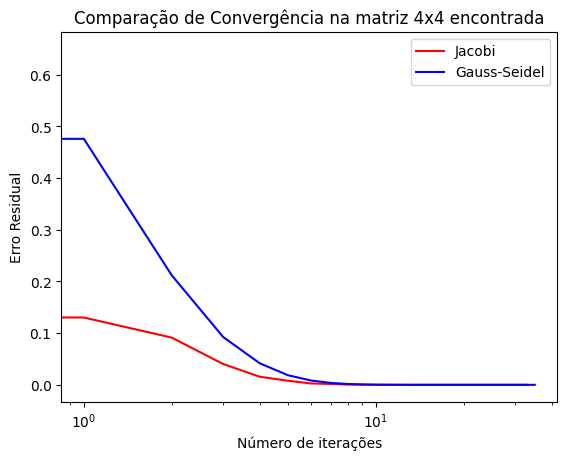

In [266]:
plt.figure()
sns.lineplot(data=residual_j, label="Jacobi", color="red")
sns.lineplot(data=residual_gs, label="Gauss-Seidel", color="blue")
plt.xscale("log")
plt.title("Comparação de Convergência na matriz 4x4 encontrada")
plt.xlabel("Número de iterações")
plt.ylabel("Erro Residual")
plt.show()

Assim, com o gráfico acima vemos que a estratégia funcionou e, realmente, o método de Jacobi converge mais rápido que o de Gauss-Seidel para a matriz encontrada

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

In [ ]:
ruido = np.random.randn(4, 4) * 1e-3

# Cenário 1: Perturbação Geral
matriz_com_ruido = matriz_rara + ruido
rho_J_geral, rho_GS_geral = calcular_raios(matriz_com_ruido)

# Cenário 2: Perturbação apenas fora da diagonal
ruido_fora = ruido.copy()
np.fill_diagonal(ruido_fora, 0)
matriz_com_ruido_fora_diagonal = matriz_rara + ruido_fora
rho_J_fora, rho_GS_fora = calcular_raios(matriz_com_ruido_fora_diagonal)

print("Sem Perturbação (Original):")
rho_J_orig, rho_GS_orig = calcular_raios(matriz_rara)
print(f"Jacobi: {rho_J_orig:.4f} | Gauss-Seidel: {rho_GS_orig:.4f}")

print("Perturbação Geral:")
print(f"Jacobi: {rho_J_geral:.4f} | Gauss-Seidel: {rho_GS_geral:.4f}")

print("Perturbação Fora da Diagonal:")
print(f"Jacobi: {rho_J_fora:.4f} | Gauss-Seidel: {rho_GS_fora:.4f}")

Sem Perturbação (Original):
Jacobi: 0.4371 | Gauss-Seidel: 0.4465
Perturbação Geral:
Jacobi: 0.4375 | Gauss-Seidel: 0.4470
Perturbação Fora da Diagonal:
Jacobi: 0.4376 | Gauss-Seidel: 0.4471


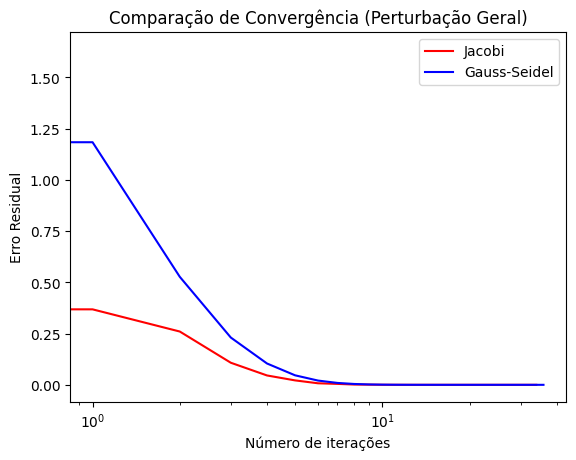

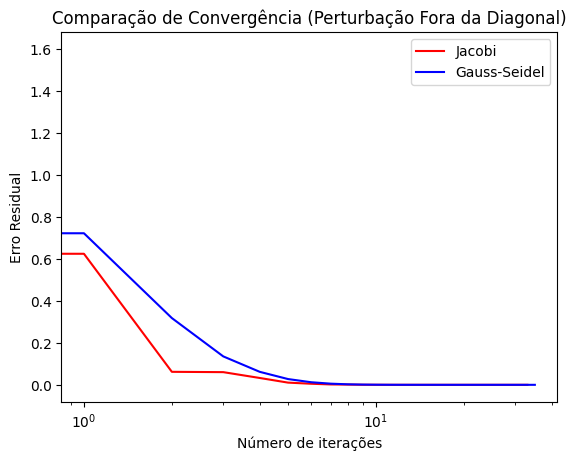

In [254]:
b_geral = matriz_com_ruido @ np.random.randn(4)
x_j_geral, errors_j_geral, residual_j_geral = jacobi(matriz_com_ruido, b_geral)
x_gs_geral, errors_gs_geral, residual_gs_geral = gauss_seidel(matriz_com_ruido, b_geral)

plt.figure()
sns.lineplot(data=residual_j_geral, label="Jacobi", color="red")
sns.lineplot(data=residual_gs_geral, label="Gauss-Seidel", color="blue")
plt.xscale("log")
plt.title("Comparação de Convergência (Perturbação Geral)")
plt.xlabel("Número de iterações")
plt.ylabel("Erro Residual")
plt.show()

b_fora = matriz_com_ruido_fora_diagonal @ np.random.randn(4)
x_j_fora, errors_j_fora, residual_j_fora = jacobi(matriz_com_ruido_fora_diagonal, b_fora)
x_gs_fora, errors_gs_fora, residual_gs_fora = gauss_seidel(matriz_com_ruido_fora_diagonal, b_fora)

# Plot
plt.figure()
sns.lineplot(data=residual_j_fora, label="Jacobi", color="red")
sns.lineplot(data=residual_gs_fora, label="Gauss-Seidel", color="blue")
plt.xscale("log")
plt.title("Comparação de Convergência (Perturbação Fora da Diagonal)")
plt.xlabel("Número de iterações")
plt.ylabel("Erro Residual")
plt.show()

## Comentários:
Vemos que somando uma matriz aleatória com elementos da ordem de $10^{-3}$, tanto geral como apenas fora da diagonal, o raio espectral das matrizes de iteração de cada método não sofrem muita alteração. Pelos gráficos acima a gente percebe que o comportamento comparativo do Erro Residual permaneceu o mesmo, apenas alterando os valores iniciais e a velocidade de convergência.

Isso causou um pouco de estranheza para mim, pois eu pensava que perturbar apenas fora da diagonal deveria afetar mais negativamente o comportamento dos algoritmos, já que afeta o critério da diagonal dominante. Creio que a baixa interferência dessa ação ocorreu devido a ordem dos valores adicionados, que não fizeram muita diferença.

Abaixo testei para ruído na ordem de $10^{-1}$:

In [258]:
ruido = np.random.randn(4, 4) * 1e-1

# Cenário 1: Perturbação Geral
matriz_com_ruido = matriz_rara + ruido
rho_J_geral, rho_GS_geral = calcular_raios(matriz_com_ruido)

# Cenário 2: Perturbação apenas fora da diagonal
ruido_fora = ruido.copy()
np.fill_diagonal(ruido_fora, 0)
matriz_com_ruido_fora_diagonal = matriz_rara + ruido_fora
rho_J_fora, rho_GS_fora = calcular_raios(matriz_com_ruido_fora_diagonal)

print("Sem Perturbação (Original):")
rho_J_orig, rho_GS_orig = calcular_raios(matriz_rara)
print(f"Jacobi: {rho_J_orig:.4f} | Gauss-Seidel: {rho_GS_orig:.4f}\n")

print("Perturbação Geral:")
print(f"Jacobi: {rho_J_geral:.4f} | Gauss-Seidel: {rho_GS_geral:.4f}\n")

print("Perturbação Fora da Diagonal:")
print(f"Jacobi: {rho_J_fora:.4f} | Gauss-Seidel: {rho_GS_fora:.4f}")

Sem Perturbação (Original):
Jacobi: 0.4371 | Gauss-Seidel: 0.4465

Perturbação Geral:
Jacobi: 0.5406 | Gauss-Seidel: 0.6509

Perturbação Fora da Diagonal:
Jacobi: 0.5900 | Gauss-Seidel: 0.7126


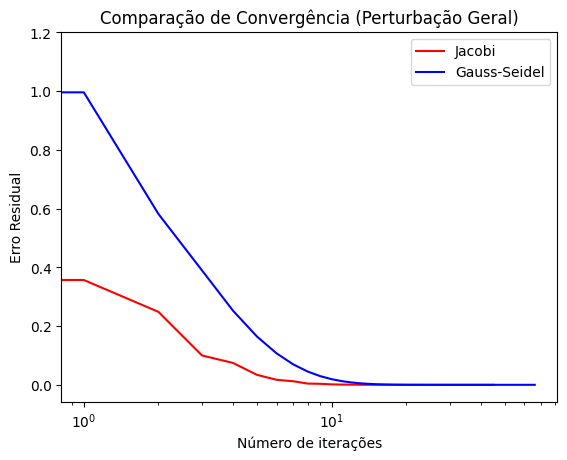

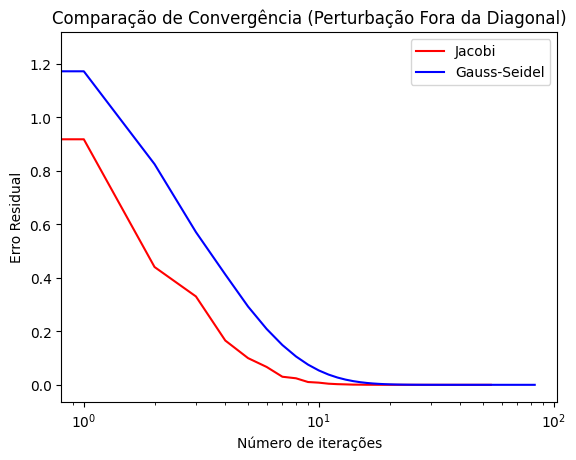

In [259]:
b_geral = matriz_com_ruido @ np.random.randn(4)
x_j_geral, errors_j_geral, residual_j_geral = jacobi(matriz_com_ruido, b_geral)
x_gs_geral, errors_gs_geral, residual_gs_geral = gauss_seidel(matriz_com_ruido, b_geral)

plt.figure()
sns.lineplot(data=residual_j_geral, label="Jacobi", color="red")
sns.lineplot(data=residual_gs_geral, label="Gauss-Seidel", color="blue")
plt.xscale("log")
plt.title("Comparação de Convergência (Perturbação Geral)")
plt.xlabel("Número de iterações")
plt.ylabel("Erro Residual")
plt.show()

b_fora = matriz_com_ruido_fora_diagonal @ np.random.randn(4)
x_j_fora, errors_j_fora, residual_j_fora = jacobi(matriz_com_ruido_fora_diagonal, b_fora)
x_gs_fora, errors_gs_fora, residual_gs_fora = gauss_seidel(matriz_com_ruido_fora_diagonal, b_fora)

# Plot
plt.figure()
sns.lineplot(data=residual_j_fora, label="Jacobi", color="red")
sns.lineplot(data=residual_gs_fora, label="Gauss-Seidel", color="blue")
plt.xscale("log")
plt.title("Comparação de Convergência (Perturbação Fora da Diagonal)")
plt.xlabel("Número de iterações")
plt.ylabel("Erro Residual")
plt.show()

## Comentários:
Aqui podemos ver que a perturbação, mesmo que 100 vezes maior, ainda manteve o mesmo comportamento de convergência de ambos os algoritmos. Porém, podemos ver que a variação no raio espectral foi bem maior, levando a crer que caso continuássemos aumentando esse ruído, o raio espectral passaria de 1 e faria os algoritmos divergirem.
Além disso, podemos notar que a perturbação fora da diagonal afetou mais negativamente o raio espectral, o que é o comportamento esperado já que diminui o fator "diagonal dominante".